# Box model using ATom data - including nitrogen related data

---

## ATom data

- This notebook makes use of measurements from deployment 1 of NASA's Atmospheric Tomography Mission (ATom), which was carried out in June-August 2016 and consisted of regular 0.2–12 km profiling. (https://doi.org/10.5194/essd-15-3299-2023)
- In this notebook we will look at a dataset containing mixing ratios of hydrogen oxides measured by the Airborne Tropospheric Hydrogen Oxides Sensor (ATHOS) from this deployment, and use it to build up an atmospheric 1-box, 0-dimensional model of OH concentrations. (https://doi.org/10.3334/ORNLDAAC/1877)
- https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf

---

## Inspect dataset

In [1]:
import pandas as pd
df = pd.read_csv("MDS_atom1_2016_summer_with_no_no2_oh_ho2_full_js.csv")

In [2]:
df.shape

(6550, 144)

In [3]:
df.head()

,Unnamed: 0,UTC_Start_dt,ATom_parcel,Start_UTC,Date,Research Flight Number,Latitude,Longitude,Altitude,Pres,...,jNO2_dnwFrac_CAFS,jNO3_NO2_O3P_CAFS,jNO3_NO_O2_CAFS,jO3_O2_O1D_CAFS,jO3_dnwFrac_CAFS,jPAN_CH3COO2_NO2_CAFS,jPAN_CH3COO_NO3_CAFS,jPropanal_CH2CH3_HCO_CAFS,lat,lon
0,121,2016-07-29 14:56:10,1000122,53770,20160729,1,33.01171,-118.89800,8804.58,343.334,...,0.668625,0.210835,0.025632,0.000009,0.703450,2.479964e-07,1.062842e-07,0.000018,33.01171,241.10200
1,124,2016-07-29 14:56:40,1000125,53800,20160729,1,32.96985,-118.95240,8931.10,337.478,...,0.665000,0.212448,0.025815,0.000009,0.702175,2.504532e-07,1.073371e-07,0.000018,32.96985,241.04760
2,127,2016-07-29 14:57:10,1000128,53830,20160729,1,32.92798,-119.00677,9057.14,331.741,...,0.660525,0.214809,0.026108,0.000009,0.696450,2.547722e-07,1.091881e-07,0.000019,32.92798,240.99323
3,136,2016-07-29 14:58:40,1000137,53920,20160729,1,32.80281,-119.16970,9425.14,315.391,...,0.644500,0.221572,0.026932,0.000010,0.690775,2.613555e-07,1.120095e-07,0.000020,32.80281,240.83030
4,139,2016-07-29 14:59:10,1000140,53950,20160729,1,32.76114,-119.22341,9550.39,309.998,...,0.640600,0.223360,0.027156,0.000010,0.689000,2.626297e-07,1.125556e-07,0.000021,32.76114,240.77659


Filtering out the dataset to only keep the columns of interest:

In [4]:
df = df[['Temp', 'Pres','UTC_Start_dt', 'lat', 'lon', 'Altitude', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'OH_ATHOS', 'HO2_ATHOS', 'CO_M', 'CH4_M', 'PAN_M', 'NOX_M', 'NO_CL', 'HNO3_M']]
df

,Temp,Pres,UTC_Start_dt,lat,lon,Altitude,jO3_O2_O1D_CAFS,O3_M,H2O_M,OH_ATHOS,HO2_ATHOS,CO_M,CH4_M,PAN_M,NOX_M,NO_CL,HNO3_M
0,249.265,343.334,2016-07-29 14:56:10,33.01171,241.10200,8804.58,0.000009,8.640570e-08,0.000447,0.300,6.444,7.233967e-08,0.000002,2.855530e-10,9.948500e-11,0.063649,3.272000e-10
1,248.771,337.478,2016-07-29 14:56:40,32.96985,241.04760,8931.10,0.000009,7.601130e-08,0.000332,0.300,5.367,6.900650e-08,0.000002,2.855530e-10,9.693500e-11,0.063389,3.104400e-10
2,248.851,331.741,2016-07-29 14:57:10,32.92798,240.99323,9057.14,0.000009,8.291030e-08,0.000158,0.300,4.633,7.108760e-08,0.000002,2.855530e-10,9.569200e-11,0.074402,3.491900e-10
3,246.160,315.391,2016-07-29 14:58:40,32.80281,240.83030,9425.14,0.000010,8.132570e-08,0.000169,0.276,6.063,6.804040e-08,0.000002,2.855530e-10,9.645400e-11,0.073041,3.308700e-10
4,245.201,309.998,2016-07-29 14:59:10,32.76114,240.77659,9550.39,0.000010,8.148520e-08,0.000207,0.276,6.233,6.748330e-08,0.000002,2.855530e-10,1.144770e-10,0.069717,2.892000e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6545,287.376,734.283,2016-08-23 19:51:00,34.94797,242.36580,2818.77,0.000048,5.419620e-08,0.007266,0.227,43.328,1.485790e-07,0.000002,2.055130e-10,4.076800e-11,0.010443,1.799500e-10
6546,288.683,749.875,2016-08-23 19:51:30,34.91515,242.35962,2641.88,0.000047,5.082710e-08,0.007460,0.227,43.173,1.320212e-07,0.000002,2.055130e-10,4.127300e-11,0.014422,1.794200e-10
6547,290.545,771.085,2016-08-23 19:52:00,34.88332,242.34174,2403.69,0.000046,5.125980e-08,0.007838,0.240,43.017,1.325316e-07,0.000002,2.055130e-10,7.323400e-11,0.015064,1.858900e-10
6548,291.259,777.013,2016-08-23 19:52:30,34.85163,242.32323,2339.75,0.000046,5.167830e-08,0.007777,0.240,48.457,1.355386e-07,0.000002,2.055130e-10,7.178500e-11,0.021050,1.843600e-10


In [5]:
from datetime import datetime, timezone
import numpy as np
from pytz import timezone
df["UTC_Start_dt"] = pd.to_datetime(df["UTC_Start_dt"])
df['UTC_Start_dt'] = df['UTC_Start_dt'].dt.tz_localize('UTC')
df["UTC_Start_dt"] = df["UTC_Start_dt"].dt.tz_convert('America/New_York')
df['date'] = df['UTC_Start_dt']
df['date']

0      2016-07-29 10:56:10-04:00
1      2016-07-29 10:56:40-04:00
2      2016-07-29 10:57:10-04:00
3      2016-07-29 10:58:40-04:00
4      2016-07-29 10:59:10-04:00
                  ...           
6545   2016-08-23 15:51:00-04:00
6546   2016-08-23 15:51:30-04:00
6547   2016-08-23 15:52:00-04:00
6548   2016-08-23 15:52:30-04:00
6549   2016-08-23 15:53:30-04:00
Name: date, Length: 6550, dtype: datetime64[ns, America/New_York]

## Finding $[M]$
For rate constants - temperature dependent so use Arrhenius equation: $k = Ae^{-\frac{E_a}{RT}}$

Convert units for species so that everything is in units of $molecules \: cm^{-3}$ and calculate $[M]$ using $[M] = \frac{p}{kT}$ ($p$ is pressure in $Pa$, $k$ is Boltzmann's constant in $J \: K^-1$ and $T$ is temperature in $K$

$1 J = 1 \: kg \: m^2 \: s^{-2}$

$1 \: Pa = 1 \: N m^{-2}$

Multiply value of $[M]$ by $1 \times 10^{-6}$, so from $molecules \: m^{-3}$ to $molecules \: cm^{-3}$

In [6]:
## Unit conversions
from datetime import datetime, timezone
import numpy as np
from pytz import timezone

kb = 1.38e-23 # J K^−1 Boltzmann's constant

for i in range(len(df)):
    df.loc[i, "M"] = ((df.loc[i, "Pres"] * 100) / (kb * df.loc[i, "Temp"])) * 1e-6 ## molecules cm^3, pressure was in hPa so multiplied by 100 to Pa

df.head()

,Temp,Pres,UTC_Start_dt,lat,lon,Altitude,jO3_O2_O1D_CAFS,O3_M,H2O_M,OH_ATHOS,HO2_ATHOS,CO_M,CH4_M,PAN_M,NOX_M,NO_CL,HNO3_M,date,M
0,249.265,343.334,2016-07-29 10:56:10-04:00,33.01171,241.10200,8804.58,0.000009,8.640570e-08,0.000447,0.300,6.444,7.233967e-08,0.000002,2.855530e-10,9.948500e-11,0.063649,3.272000e-10,2016-07-29 10:56:10-04:00,9.981054e+18
1,248.771,337.478,2016-07-29 10:56:40-04:00,32.96985,241.04760,8931.10,0.000009,7.601130e-08,0.000332,0.300,5.367,6.900650e-08,0.000002,2.855530e-10,9.693500e-11,0.063389,3.104400e-10,2016-07-29 10:56:40-04:00,9.830297e+18
2,248.851,331.741,2016-07-29 10:57:10-04:00,32.92798,240.99323,9057.14,0.000009,8.291030e-08,0.000158,0.300,4.633,7.108760e-08,0.000002,2.855530e-10,9.569200e-11,0.074402,3.491900e-10,2016-07-29 10:57:10-04:00,9.660079e+18
3,246.160,315.391,2016-07-29 10:58:40-04:00,32.80281,240.83030,9425.14,0.000010,8.132570e-08,0.000169,0.276,6.063,6.804040e-08,0.000002,2.855530e-10,9.645400e-11,0.073041,3.308700e-10,2016-07-29 10:58:40-04:00,9.284376e+18
4,245.201,309.998,2016-07-29 10:59:10-04:00,32.76114,240.77659,9550.39,0.000010,8.148520e-08,0.000207,0.276,6.233,6.748330e-08,0.000002,2.855530e-10,1.144770e-10,0.069717,2.892000e-10,2016-07-29 10:59:10-04:00,9.161310e+18


## Source rate

Calculate $[O^1D]$ using $[O^1D]_{SS} = \frac{J[O_3]}{k_1[H_2O] + k_2[M]}$

(After the conversion to $molecules \: cm^{-3}$ for the other concentrations, $[M]$ cancels out to become 1, but it is technically still included in the rate equation)

Need to calculate $[O^1D]$ indirectly using data for $[O_3]$

Production

$O_3 + hv → O_2 + O(^1D)$

Loss

$O(^1D) + M → O(^3P) + M$

$O(^1D) + H_2O → 2OH$

Assumed to be in steady state - due to its high reactivity and short lifetime

So $\frac{d[O^1D]}{dt} = J[O_3] - k_1[O^1D][H_2O] - k_2[O^1D] = 0$

$[O^1D]_{SS} = \frac{J[O_3]}{k_1[H_2O] + k_2[M]}$

$(M = \frac{p}{kT})$

$k = Ae^{-\frac{E_a}{RT}}$ to calculate temperature dependent rate constants

Additional sources being added:

$HO_2 + NO → OH + NO_2$

source rate = $k[HO_2][NO]$

$HO_2 + O_3→OH + 2O_2$

source rate = $k[HO_2][O_3]$

In [7]:
df['kH2O'] = 1.63e-10 * np.exp(--60/df["Temp"]) ## page 21 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kM'] = 2.15e-11 * np.exp(--110/df["Temp"]) ## page 21 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kNO'] = 3.44e-12 * np.exp(--260/df["Temp"]) ## page 83 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kHO2'] = 1.0e-14 * np.exp(-490/df["Temp"]) ## page 67 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf

# New column for conversion from mole fraction to molecules cm^-3
df["O3"] = df["O3_M"] * df["M"]
df["H2O"] = df["H2O_M"] * df["M"]
df["HO2"] = df["HO2_ATHOS"] * 1e-12 * df["M"]
df["NO"] = df["NOX_M"] * df["M"]

df["[OH]_measured"] = df["OH_ATHOS"] * 1e-12 * df["M"] # in ppt

df["O1D"] = (df["jO3_O2_O1D_CAFS"] * df["O3_M"]) / ((df['kH2O'] * df["H2O_M"]) + (df['kM']))

df.columns

Index(['Temp', 'Pres', 'UTC_Start_dt', 'lat', 'lon', 'Altitude',
       'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'OH_ATHOS', 'HO2_ATHOS', 'CO_M',
       'CH4_M', 'PAN_M', 'NOX_M', 'NO_CL', 'HNO3_M', 'date', 'M', 'kH2O', 'kM',
       'kNO', 'kHO2', 'O3', 'H2O', 'HO2', 'NO', '[OH]_measured', 'O1D'],
      dtype='object')

In [8]:
for i in range(len(df)):
    df.loc[i, "O1D"] = (df["jO3_O2_O1D_CAFS"][i] * df["O3_M"][i]) / ((df['kH2O'][i] * df["H2O_M"][i]) + (df['kM'][i]))
    
    df.loc[i, "source"] = (2 * df['kH2O'][i] * df["O1D"][i] * df["H2O"][i])
    #+ (df['kNO'][i] * df["HO2"][i] * df["NO"][i]) + (df['kHO2'][i] * df["HO2"][i] * df["O3"][i])
# print(df["O1D"].mean())
print(df["source"].mean())
df.head()
# source should be around 10e5 molecules cm^-3 s^-1

print("Source rates (in molecules cm^-3 s^-1):")
print("O1D contribution: ", (2 * df['kH2O'] * df["O1D"] * df["H2O"]).mean())
print("NO contribution: ", (df['kNO'] * df["HO2"] * df["NO"]).mean())
print("HO2 contribution: ", (df['kHO2'] * df["HO2"] * df["O3"]).mean())

714621.1551027566
Source rates (in molecules cm^-3 s^-1):
O1D contribution:  714621.1551027566
NO contribution:  1319199.8459436973
HO2 contribution:  178178.66999201934


The graph shows that the source rate in OH is higher at low altitudes and lower at high altitudes - we can link this to the source of OH being the reaction between $O(^1D)$ and $H_2O$. Therefore this varying rate must be related to one (or both) of these species.

## Box model equation to find [OH]

## Steady state of OH and sinks

Use the sink rate coefficients here

$OH + CO → H + CO2$

Rate coefficient = $k[CO]$

$OH + CH_4 → CH_3 + H_2O$

Rate coefficient = $k[CH_4]$

As $\frac{d[OH]}{dt} = Σsources - Σsinks$

$\frac{d[OH]}{dt} = P(OH) - k_1[OH][CO] - k_2[CH_4][OH]$

At steady state the sources and sinks balance:

$P(OH) - k_1[OH][CO] - k_2[CH_4][OH] = 0$

As we do not know $[OH]$ (calculated) yet we cannot calculate the sink rate however we can use the steady state approximation to rearrange to find $[OH]$ from the other known values

$P(OH) = sum of source rates

$[OH] = \frac{p(OH)}{(k_1[CO] + k_2[CH4] + $k[O_3]$ + k[HNO_3]}$

Additional sinks being added:

$OH + O_3 → HO_2 + O_2$

Rate coefficient $k[O_3]$

$OH + HNO3 → H_2O + NO_2

Rate coefficient $k[HNO_3]$

In [9]:
df["source"].mean()

np.float64(714621.1551027566)

In [15]:
# Re-evaluate rate coefficients (page 17 of JPL)
df['kCO'] = 1.85e-13 * np.exp(-65/(df['Temp'])) ## page 484 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kCH4'] = 2.45e-12 * np.exp(-1775/df['Temp']) ## page 106 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf

df['kO3'] = 1.7e-12 * np.exp(-940/df["Temp"]) ## page 67 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kHO2'] = 4.8e-11 * np.exp(--250/df["Temp"]) ## page 67 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kHNO3'] = 3.7e-14 * np.exp(--240/df["Temp"]) ## page 484 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf

df["CO"] = df['CO_M'] * df["M"]
df["CH4"] = df['CH4_M'] * df["M"]
df["HNO3"] = df['HNO3_M'] * df["M"]

# Calculating [OH]
for i in range(len(df)):
    df.loc[i, "[OH]_calc"] = (df.loc[i, "source"]) / ((df['kCO'][i] * df["CO"][i]) + (df['kCH4'][i] * df["CH4"][i]))
    #+ (df['kHO2'][i] * df["HO2"][i]) + (df['kHNO3'][i] * df["HNO3"][i]) + (df['kO3'][i] * df["O3"][i]) + (df['kHO2'][i] * df["HO2"][i]))

# Sink contributions
print("Sink rate coefficients (in molecules^-1 cm^3 s^-1):")
print("CO contribution: ", (df['kCO'] * df["CO"]).mean())
print("CH4 contribution: ", (df['kCH4'] * df["CH4"]).mean())
print("O3 contribution: ", (df['kO3'] * df["O3"]).mean())
print("HO2 contribution: ", (df['kHO2'] * df["HO2"]).mean())
print("HNO3 contribution: ", (df['kHNO3'][i] * df["HNO3"][i]).mean())

# print(1.7e-12 * np.exp(-940/298))

Sink rate coefficients (in molecules^-1 cm^3 s^-1):
CO contribution:  0.1576213023345094
CH4 contribution:  0.07669693114608837
O3 contribution:  0.02803799405727622
HO2 contribution:  0.021753598617772762
HNO3 contribution:  0.0009045451242641961


## Plotting calculated $[OH]_{SS}$ vs measured $[OH]$ from ATom data

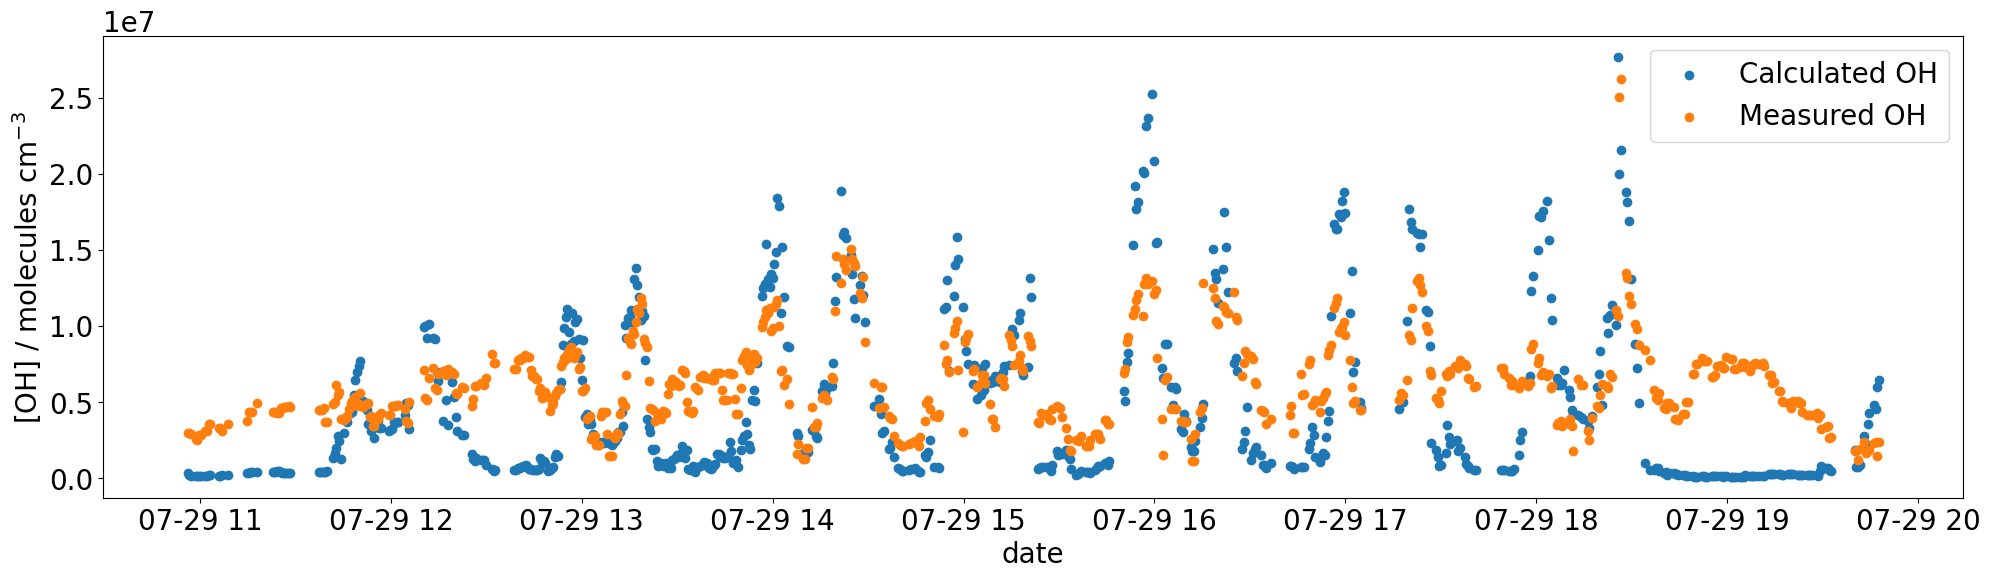

In [16]:
# Plotting the [OH] calculated vs measured

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':20})
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][df["date"] < "2016-07-30"], y = df["[OH]_calc"][df["date"] < "2016-07-30"], label = "Calculated OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend()
# fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][df["date"] < "2016-07-30"], y = df["[OH]_measured"][df["date"] < "2016-07-30"], label = "Measured OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend(prop={'size':20})

import pickle
with open("comparison.pkl", "wb") as f:
    pickle.dump(fig, f)

Comparison plots for 4 days

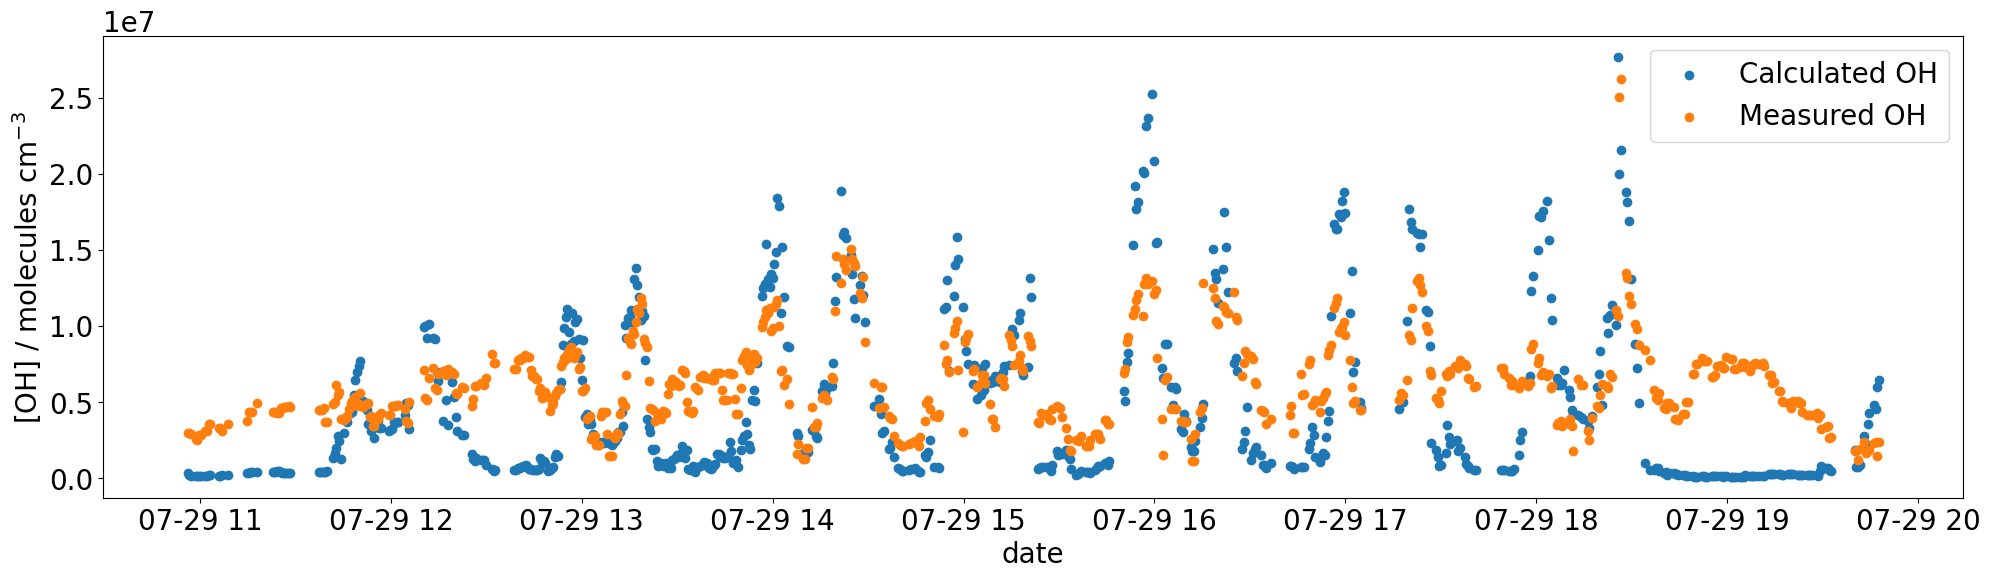

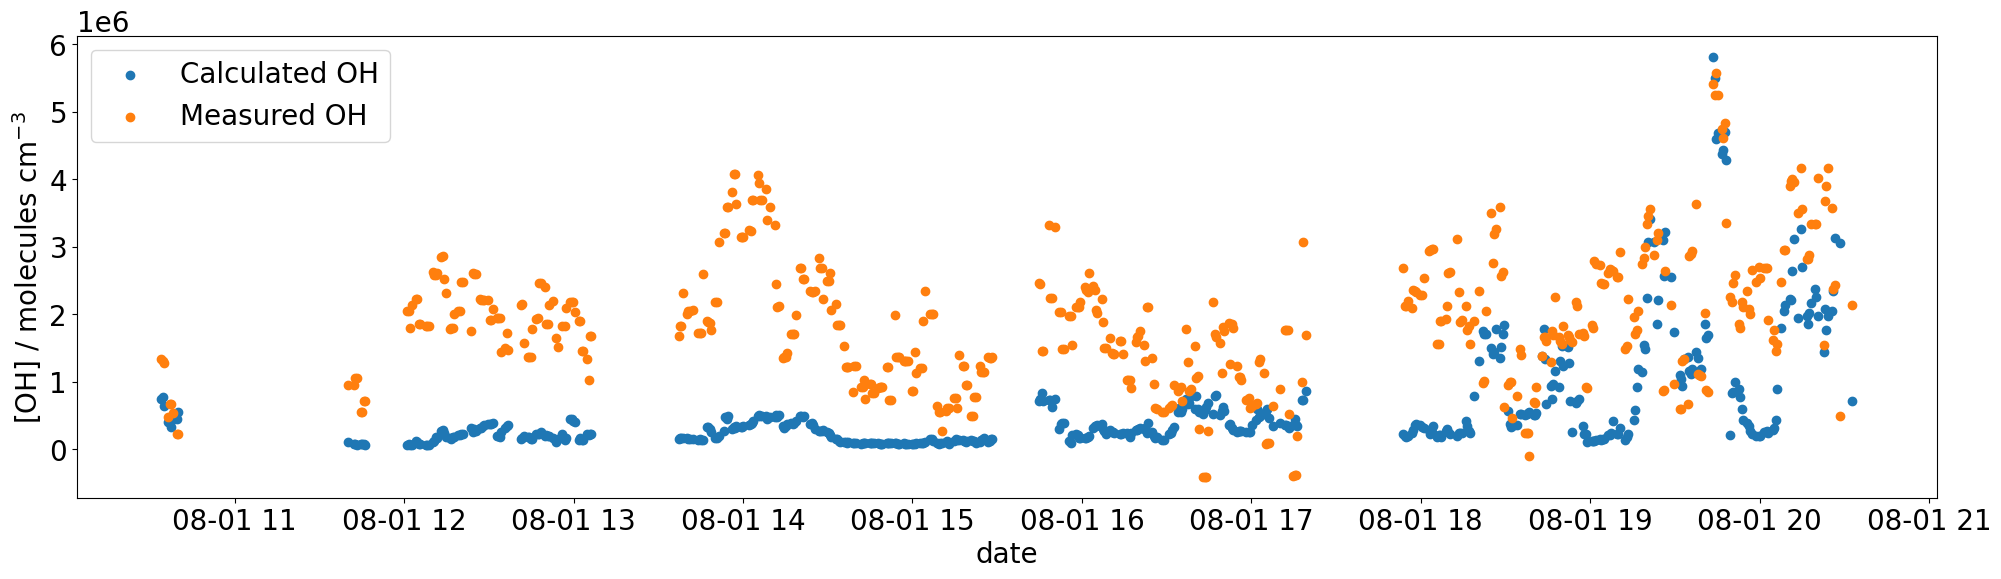

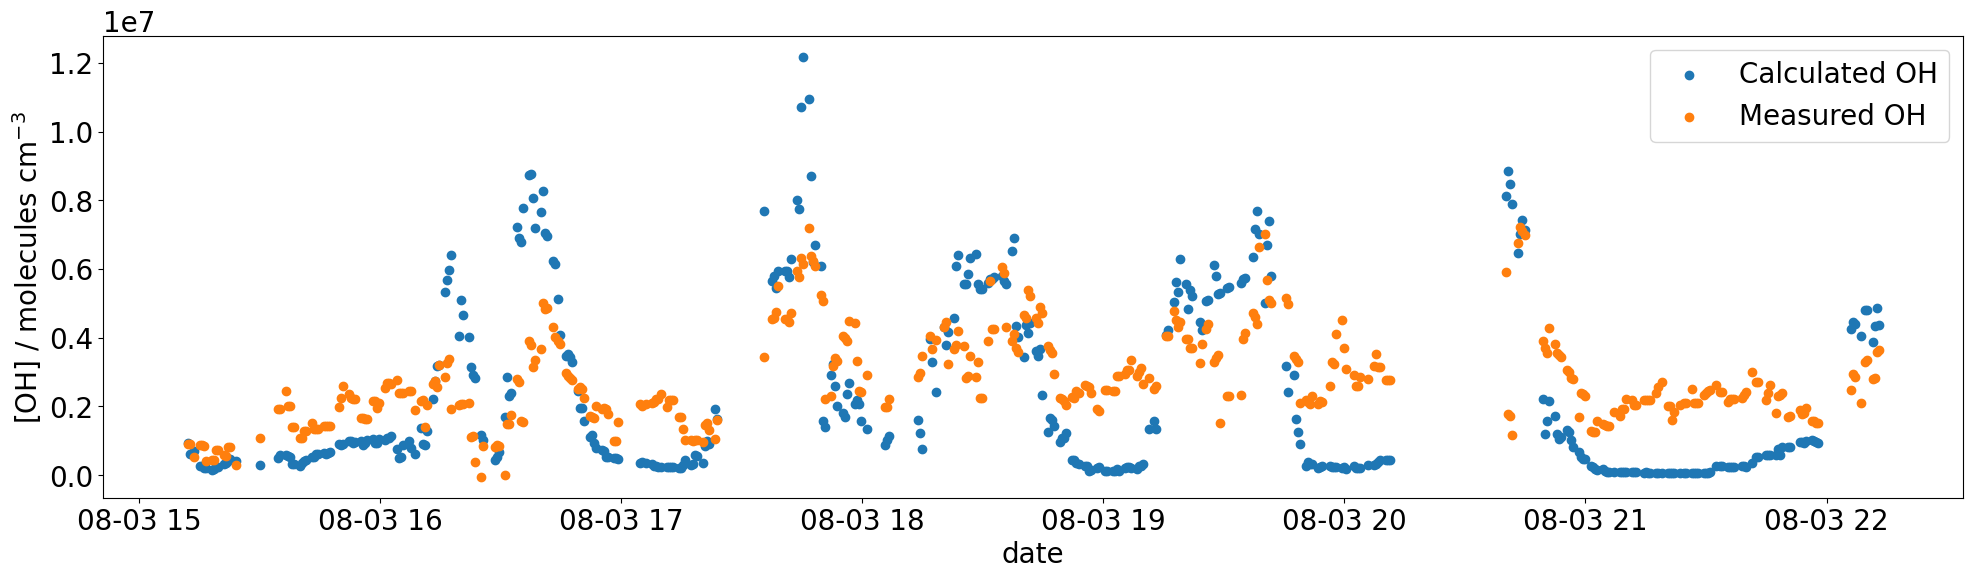

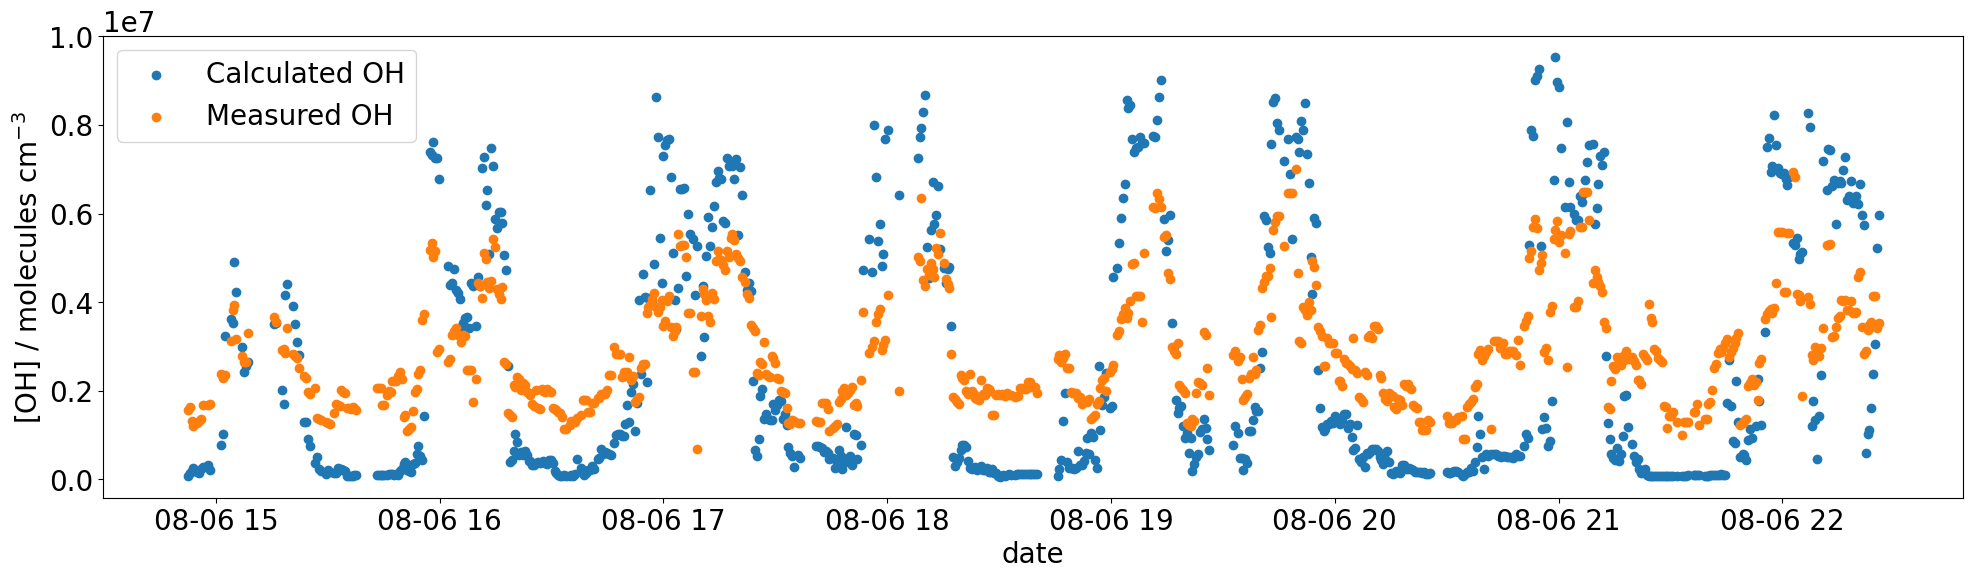

In [17]:
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], y = df["[OH]_calc"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "Calculated OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend()
# fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], y = df["[OH]_measured"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "Measured OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend()

fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-07-30") & (df["date"] < "2016-08-02")], y = df["[OH]_calc"][(df["date"] > "2016-07-30") & (df["date"] < "2016-08-02")], label = "Calculated OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend()
# fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-07-30") & (df["date"] < "2016-08-02")], y = df["[OH]_measured"][(df["date"] > "2016-07-30") & (df["date"] < "2016-08-02")], label = "Measured OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend()

fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-08-02") & (df["date"] < "2016-08-04")], y = df["[OH]_calc"][(df["date"] > "2016-08-02") & (df["date"] < "2016-08-04")], label = "Calculated OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend()
# fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-08-02") & (df["date"] < "2016-08-04")], y = df["[OH]_measured"][(df["date"] > "2016-08-02") & (df["date"] < "2016-08-04")], label = "Measured OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend()

fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], y = df["[OH]_calc"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], label = "Calculated OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend()
# fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], y = df["[OH]_measured"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], label = "Measured OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend()

In [13]:
from sklearn.linear_model import LinearRegression
import sklearn
X = df[["[OH]_measured"]][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")]
y = df["[OH]_calc"][(df["date"] > "2016-07-28") & (df["date"] < "2016-08-01")]
print(sklearn.metrics.r2_score(X, y))

X = df[["[OH]_measured"]][(df["date"] > "2016-07-30") & (df["date"] < "2016-08-02")]
y = df["[OH]_calc"][(df["date"] > "2016-07-30") & (df["date"] < "2016-08-02")]
print(sklearn.metrics.r2_score(X, y))

X = df[["[OH]_measured"]][(df["date"] > "2016-08-02") & (df["date"] < "2016-08-04")]
y = df["[OH]_calc"][(df["date"] > "2016-08-02") & (df["date"] < "2016-08-04")]
print(sklearn.metrics.r2_score(X, y))

X = df[["[OH]_measured"]][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")]
y = df["[OH]_calc"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")]
print(sklearn.metrics.r2_score(X, y))

X = df[["[OH]_measured"]]
y = df["[OH]_calc"]
print(sklearn.metrics.r2_score(X, y))

-4.475418551958348
-3.799260124744757
-4.26772994288505
-4.901034955555837
-1.3122583292706125


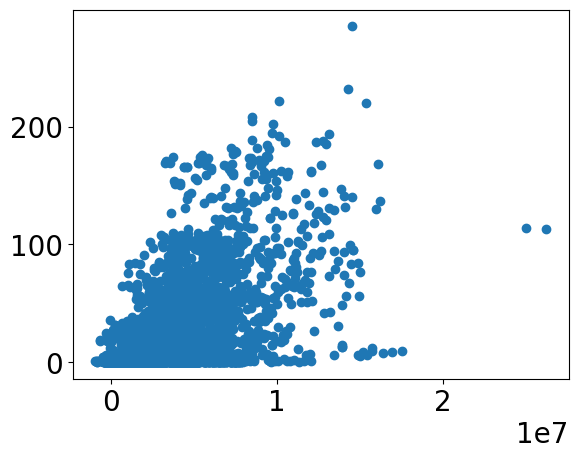

In [14]:
plt.scatter(df["[OH]_measured"], df["[OH]_calc"])